# **Rep. 2. Checkpoint 2. Mov. Geométrico Browniano**
- Paola A. Figueroa Álvarez
- 17/feb/2026
- Simulación de procesos financieros


## **1. Construcción del portafolio con datos reales**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt

In [14]:
stocks = ["JPM", "UNH", "TSM", "JNJ"]
#weights = np.array([0.35,0.30,0.20,0.15])
weights = np.array([0.25,0.25,0.25,0.25])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

In [15]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
prices.head()

Ticker,JNJ,JPM,TSM,UNH
Date,,,,
2023-02-21,145.263321,130.052155,83.642021,465.107391
2023-02-22,145.061050,129.055542,82.868973,462.816528
2023-02-23,145.015076,130.089401,85.970711,465.467163
2023-02-24,143.396973,131.262955,84.090576,458.499664
2023-02-27,143.084366,132.408615,83.317535,457.543549


In [16]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,JNJ,JPM,TSM,UNH
Date,,,,
2023-02-22,-0.001392,-0.007663,-0.009242,-0.004925
2023-02-23,-0.000317,0.008011,0.037429,0.005727
2023-02-24,-0.011158,0.009021,-0.021869,-0.014969
2023-02-27,-0.002180,0.008728,-0.009193,-0.002085
2023-02-28,-0.015228,0.008371,-0.002635,-0.015269


In [17]:
mean_returns = returns.mean()
cov_matrix = returns.cov()
print("Media diaria retornos:", mean_returns)
print("\\nMatriz de covarianza:", cov_matrix)

Media diaria retornos: Ticker
JNJ    0.000747
JPM    0.001257
TSM    0.002246
UNH   -0.000366
dtype: float64
\nMatriz de covarianza: Ticker       JNJ       JPM       TSM       UNH
Ticker                                        
JNJ     0.000117  0.000019 -0.000046  0.000032
JPM     0.000019  0.000219  0.000093  0.000030
TSM    -0.000046  0.000093  0.000564 -0.000027
UNH     0.000032  0.000030 -0.000027  0.000511


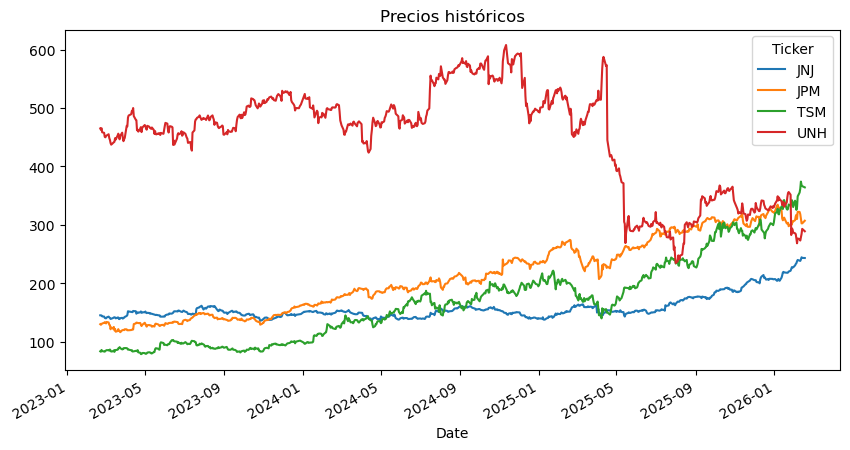

In [18]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

## **2. Exploración de datos del portafolio**

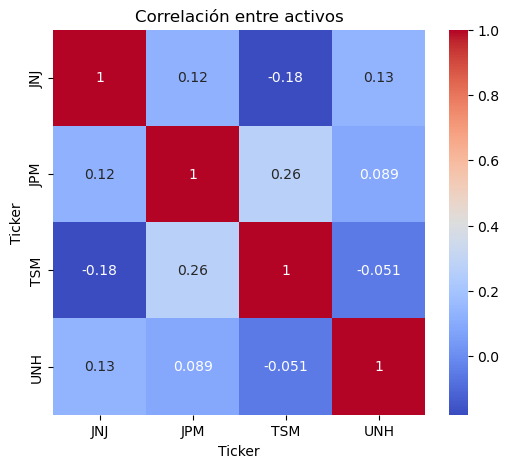

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

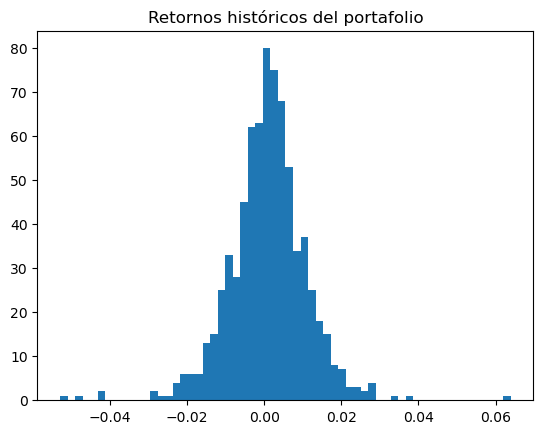

Volatilidad histórica diaria: 0.01003855529606513


In [20]:
# Retornos históricos del portafolio
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

## **3. Simulación Monte Carlo del portafolio**

In [21]:
# Parámetros de simulación
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [22]:
# Simulación de trayectorias
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)
    # Cada iteración genera una trayectoria posible del valor del portafolio.

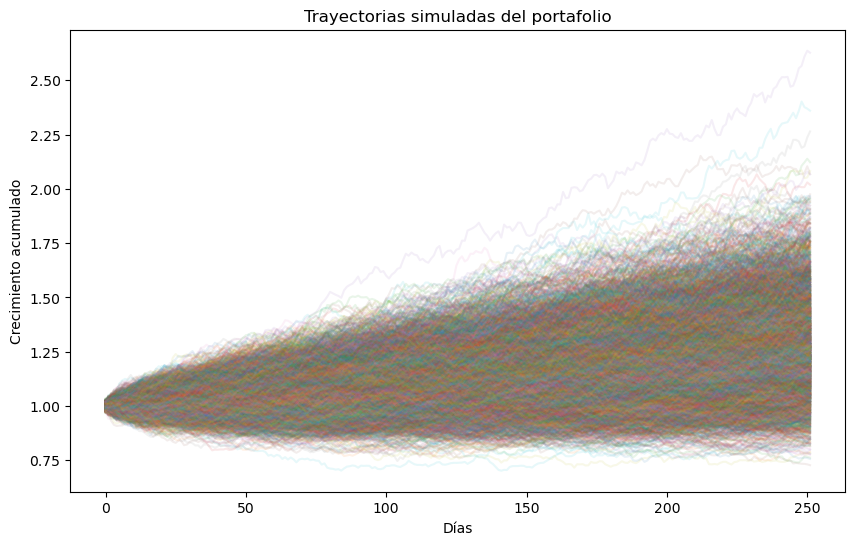

In [23]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

## **4. Análisis de la simulación**

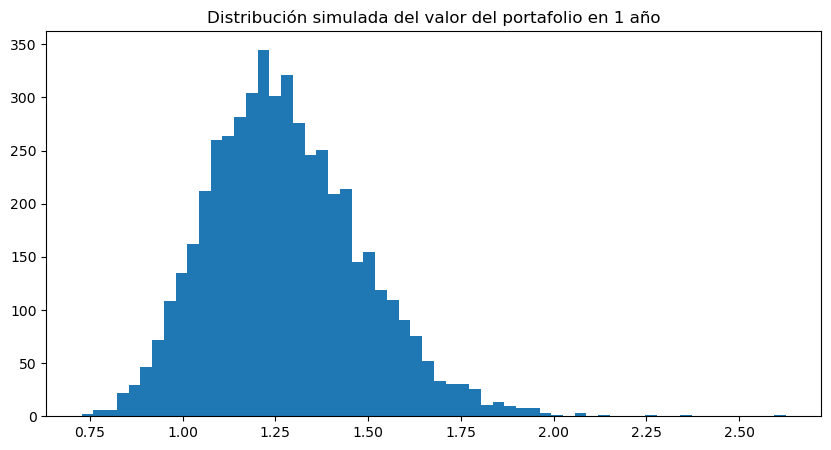

Valor esperado final: 1.2777908013731356
Probabilidad de pérdida: 0.0726
Valor máximo observado:  2.627005381464699
Valor mínimo observado:  0.7275099945137251


In [24]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))
print("Valor máximo observado: ", final_values.max())
print("Valor mínimo observado: ", final_values.min())

## **5.- Análisis comparativo del portafolio**

Con el portafolio 1, establecido por stocks = ["JPM", "UNH", "TSM", "JNJ"] y pesos [0.35,0.30,0.20,0.15]
- Valor esperado final: 1.2967551866367282
- Probabilidad de pérdida: 0.0454
- Valor máximo observado:  2.1296208430429546
- Valor mínimo observado:  0.70849634712549


**¿Qué activos están más correlacionados?**
- Los activos con mayor correlación positiva son JPM  y TSM, con una covarianza de 0.000093. Por el contrario, TSM y JNJ presentan una correlación negativa (-0.000046).

**¿El portafolio parece estable o muy variable?**
El portafolio es relativamente estable, considerando que la probabilidad de pérdida es baja (4.54%) y el valor esperado final es de 1.2967, lo que indica una tendencia de crecimiento moderada con riesgo controlado.

**¿Cuál activo parece dominar el comportamiento del portafolio?**
- JPM domina el comportamiento debido a que tiene el mayor peso asignado (35%) y una media de retornos diaria sólida (0.001257), seguido de cerca por UNH (30%).

**¿Las trayectorias simuladas son similares entre sí o muy distintas?**
- Las trayectorias muestran un comportamiento similar en su tendencia central (hacia el valor esperado de 1.29), pero presentan variaciones individuales significativas debido al componente aleatorio del movimiento Browniano, alcanzando un máximo de 2.12 y un mínimo de 0.70.

**¿La dispersión aumenta con el tiempo?**
- Sí. En el modelo de Movimiento Geométrico Browniano, la incertidumbre y la varianza son proporcionales al tiempo. A medida que avanza el horizonte de simulación, el abanico de posibles resultados (dispersión) se vuelve más amplio.

**¿Qué observas en la distribución final del portafolio?**
- Se observa una distribución log-normal, característica de este modelo. La mayoría de los escenarios terminan cerca del valor esperado, pero existe una asimetría hacia la derecha (valores altos) y una cola muy reducida por debajo de 1.0, reflejada en la baja probabilidad de pérdida (0.0454).

Con un segundo portafolio que posee los mismos stocks pero con pesos equitativos, estos fueron los resultados:
- Valor esperado final: 1.2777908013731356
- Probabilidad de pérdida: 0.0726
- Valor máximo observado:  2.627005381464699
- Valor mínimo observado:  0.7275099945137251

El ajuste de un portafolio  revela que la distribución de los pesos y el horizonte temporal son determinantes críticos del riesgo y el retorno. Al transicionar de un portafolio optimizado a uno de ponderaciones equitativas, se observa que, aunque la diversificación teórica aumenta, la probabilidad de pérdida también puede elevarse (de un 4.54% a un 7.26%) si se otorga mayor peso a activos con volatilidades más altas o retornos promedio más bajos. Asimismo, el modelo demuestra que la incertidumbre es una función creciente del tiempo, provocando que las trayectorias se dispersen cada vez más conforme se extiende el horizonte, resultando en una distribución final de tipo log-normal donde los escenarios de ganancias extremas son posibles pero la mayoría de los resultados se agrupan en torno a un valor esperado influenciado por la deriva histórica de los activos seleccionados.